## **Health Insurance Marketplace Project**
---

### Executive Summary

This project analyzes over 12 million ACA (Affordable Care Act) Marketplace premium records from CMS(Centers for Medicare & Medicaid Services) (2014–2016) to understand how health insurance pricing differs across coverage tiers, plan types, geographic regions, and enrollee characteristics.

The analysis combines SQL-based relational joins, extensive data cleaning, statistical analysis, and visualization to answer practical pricing questions relevant to consumers and policymakers.

Install and Import Modules into my workspace 

In [1]:
import pandas as pd # Importing the Pandas package with an alias, pd
import sqlite3 # Importing the SQL interface
import seaborn as sns
import matplotlib.pyplot as plt
import re
import numpy as np


# Importing and cleaning the data

Load my dataset into my workspace using the sqlite file to view the table names 

In [2]:
# Load dataset into workspace using SQLite connection
conn = sqlite3.connect('database.sqlite')

# Retrieve and view all table names
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
tables

,name
0,Crosswalk2015
1,Crosswalk2016
2,PlanAttributes
3,Network
4,BenefitsCostSharing
5,ServiceArea
6,BusinessRules
7,Rate


Inspect the column names and data types for each table in the dataset to verify schema structures and prepare for relational joins.


In [3]:
for table in tables['name']:
    schema = pd.read_sql(f"PRAGMA table_info({table})", conn)
    print(f"\n{table}")
    print(schema[['name', 'type']])


Crosswalk2015
                         name     type
0                       State     TEXT
1                  DentalPlan     TEXT
2                 PlanID_2014     TEXT
3               IssuerID_2014  INTEGER
4         MultistatePlan_2014     TEXT
5             MetalLevel_2014     TEXT
6         ChildAdultOnly_2014  INTEGER
7                    FIPSCode  INTEGER
8                     ZipCode  INTEGER
9              CrosswalkLevel  INTEGER
10         ReasonForCrosswalk  INTEGER
11                PlanID_2015     TEXT
12              IssuerID_2015  INTEGER
13        MultistatePlan_2015     TEXT
14            MetalLevel_2015     TEXT
15        ChildAdultOnly_2015     TEXT
16          AgeOffPlanID_2015     TEXT
17        IssuerID_AgeOff2015  INTEGER
18  MultistatePlan_AgeOff2015     TEXT
19      MetalLevel_AgeOff2015     TEXT
20  ChildAdultOnly_AgeOff2015     TEXT

Crosswalk2016
                         name     type
0                       State     TEXT
1                  DentalPlan     

In [4]:
# Inspecting each table
for table in tables['name']:
    first_row = pd.read_sql(f"SELECT * FROM {table} LIMIT 2", conn)
    
    print(f"\n{table}")
    display(first_row)


Crosswalk2015


,State,DentalPlan,PlanID_2014,IssuerID_2014,MultistatePlan_2014,MetalLevel_2014,ChildAdultOnly_2014,FIPSCode,ZipCode,CrosswalkLevel,...,PlanID_2015,IssuerID_2015,MultistatePlan_2015,MetalLevel_2015,ChildAdultOnly_2015,AgeOffPlanID_2015,IssuerID_AgeOff2015,MultistatePlan_AgeOff2015,MetalLevel_AgeOff2015,ChildAdultOnly_AgeOff2015
0,AK,Y,21989AK0010001,21989,N,Low,0,2013,0,1,...,21989AK0030001,21989,N,High,0,00000XX0000000,0,X,X,X
1,AK,Y,21989AK0010001,21989,N,Low,0,2016,0,1,...,21989AK0030001,21989,N,High,0,00000XX0000000,0,X,X,X



Crosswalk2016


,State,DentalPlan,PlanID_2015,IssuerID_2015,MultistatePlan_2015,MetalLevel_2015,ChildAdultOnly_2015,FIPSCode,ZipCode,CrosswalkLevel,...,PlanID_2016,IssuerID_2016,MultistatePlan_2016,MetalLevel_2016,ChildAdultOnly_2016,AgeOffPlanID_2016,IssuerID_AgeOff2016,MultistatePlan_AgeOff2016,MetalLevel_AgeOff2016,ChildAdultOnly_AgeOff2016
0,OR,N,10091OR0360004,10091,N,Bronze,0,41021,0,0,...,10091OR0360004,10091,N,Bronze,0,00000XX0000000,0,X,X,X
1,OR,N,10091OR0360004,10091,N,Bronze,0,41037,0,0,...,10091OR0360004,10091,N,Bronze,0,00000XX0000000,0,X,X,X



PlanAttributes


...

,BusinessYear,StateCode,IssuerId,SourceName,VersionNum,ImportDate,IssuerId2,StateCode2,ServiceAreaId,ServiceAreaName,CoverEntireState,County,PartialCounty,ZipCodes,PartialCountyJustification,RowNumber,MarketCoverage,DentalOnlyPlan
0,2014,PA,22444,HIOS,9,2014-01-21 08:29:49,22444,PA,PAS001,Geisinger Health Plan,No,42103,No,,,42,,
1,2014,PA,22444,HIOS,9,2014-01-21 08:29:49,22444,PA,PAS001,Geisinger Health Plan,No,42105,No,,,43,,



BusinessRules


,BusinessYear,StateCode,IssuerId,SourceName,VersionNum,ImportDate,IssuerId2,TIN,ProductId,StandardComponentId,...,DependentMaximumAgRule,ChildrenOnlyContractMaxChildrenRule,DomesticPartnerAsSpouseIndicator,SameSexPartnerAsSpouseIndicator,AgeDeterminationRule,MinimumTobaccoFreeMonthsRule,CohabitationRule,RowNumber,MarketCoverage,DentalOnlyPlan
0,2014,AL,82285,HIOS,7,2014-01-21 08:29:49,82285,94-2761537,,82285AL0010006,...,26,3 or more,Yes,Yes,Age on effective date,Not Applicable,"Spouse,No;Adopted Child,No;Foster Child,No;War...",14,,
1,2014,AL,82285,HIOS,7,2014-01-21 08:29:49,82285,94-2761537,,82285AL0020001,...,Not Applicable,3 or more,Yes,Yes,Age on effective date,Not Applicable,"Adopted Child,Yes;Foster Child,Yes;Stepson or ...",15,,



Rate


,BusinessYear,StateCode,IssuerId,SourceName,VersionNum,ImportDate,IssuerId2,FederalTIN,RateEffectiveDate,RateExpirationDate,...,IndividualRate,IndividualTobaccoRate,Couple,PrimarySubscriberAndOneDependent,PrimarySubscriberAndTwoDependents,PrimarySubscriberAndThreeOrMoreDependents,CoupleAndOneDependent,CoupleAndTwoDependents,CoupleAndThreeOrMoreDependents,RowNumber
0,2014,AK,21989,HIOS,6,2014-03-19 07:06:49,21989,93-0438772,2014-01-01,2014-12-31,...,29.00,,,,,,,,,14
1,2014,AK,21989,HIOS,6,2014-03-19 07:06:49,21989,93-0438772,2014-01-01,2014-12-31,...,36.95,,73.9,107.61,107.61,107.61,144.56,144.56,144.56,14


Inspecting the first row of each table to identify common fields that may serve as primary or foreign keys, while also understanding the structure and contents of each table. This initial inspection helps identify potential relationships between the tables and informs the selection of candidate join keys for further validation.

In [5]:
verification = """
SELECT
    'BusinessRules' AS Table_Name,
    COUNT(DISTINCT IssuerId) AS Unique_IssuerIds,
    COUNT(DISTINCT BusinessYear) AS Unique_BusinessYears,
    COUNT(DISTINCT StateCode) AS Unique_StateCodes
FROM BusinessRules

UNION ALL

SELECT
    'Network',
    COUNT(DISTINCT IssuerId),
    COUNT(DISTINCT BusinessYear),
    COUNT(DISTINCT StateCode)
FROM Network

UNION ALL

SELECT
    'PlanAttributes',
    COUNT(DISTINCT IssuerId),
    COUNT(DISTINCT BusinessYear),
    COUNT(DISTINCT StateCode)
FROM PlanAttributes

UNION ALL

SELECT
    'Rate',
    COUNT(DISTINCT IssuerId),
    COUNT(DISTINCT BusinessYear),
    COUNT(DISTINCT StateCode)
FROM Rate

UNION ALL

SELECT
    'ServiceArea',
    COUNT(DISTINCT IssuerId),
    COUNT(DISTINCT BusinessYear),
    COUNT(DISTINCT StateCode)
FROM ServiceArea;
"""

verification_df = pd.read_sql(verification, conn)
verification_df

,Table_Name,Unique_IssuerIds,Unique_BusinessYears,Unique_StateCodes
0,BusinessRules,910,3,39
1,Network,908,3,39
2,PlanAttributes,910,3,39
3,Rate,910,3,39
4,ServiceArea,910,3,39


In [6]:
hmany1 = """SELECT IssuerId,
       BusinessYear,
       StateCode,
       COUNT(*) AS NetworkRecords
FROM Network
WHERE IssuerId IN (38921, 45958)
GROUP BY IssuerId, BusinessYear, StateCode;"""
tguess1 = pd.read_sql(hmany1, conn)
tguess1

,IssuerId,BusinessYear,StateCode,NetworkRecords


In [7]:
hmany2 = """SELECT IssuerId,
       BusinessYear,
       StateCode,
       COUNT(*) AS RateRecords
FROM Rate
WHERE IssuerId IN (38921, 45958)
GROUP BY IssuerId, BusinessYear, StateCode
ORDER BY IssuerId, BusinessYear, StateCode;"""
tguess2 = pd.read_sql(hmany2, conn)
tguess2

,IssuerId,BusinessYear,StateCode,RateRecords
0,38921,2014,WY,288
1,45958,2014,IN,1615


Rate contains 910 unique IssuerIds, while Network contains 908. Two issuers (38921 and 45958) are present in Rate but absent from Network, accounting for 1,903 Rate records. This discrepancy will be retained as a data limitation and considered when joining the tables.

Most of the tables appear to contain a 14-digit identifier that may serve as a primary key in the respective table and as a reference key for linking related tables. However, PlanAttributes uses a different identifier format, with a two-digit suffix appended after a hyphen. This difference in structure will require further validation before determining the appropriate join keys.

In [8]:
# Verifying PlanId entries in the PlanAttributes table with the possible suffix of the PlanId
info = """
SELECT PlanId,BusinessYear,IssuerId
FROM PlanAttributes
GROUP BY PlanId,BusinessYear,IssuerId
"""
informa = pd.read_sql(info, conn)
informa.head()

,PlanId,BusinessYear,IssuerId
0,10046HI0020003-00,2016,10046
1,10046HI0020003-01,2016,10046
2,10046HI0020004-00,2016,10046
3,10046HI0020004-01,2016,10046
4,10046HI0020005-00,2016,10046


In [9]:
# Verifying if the number of the PlanId is related to the PlanId enteries in the PlanAttributes table
inf = """
SELECT PlanId,BusinessYear,IssuerId
FROM Rate
WHERE IssuerId = 10046
GROUP BY PlanId
"""
inform = pd.read_sql(inf, conn)
inform.head()

,PlanId,BusinessYear,IssuerId
0,10046HI0020003,2016,10046
1,10046HI0020004,2016,10046
2,10046HI0020005,2016,10046
3,10046HI0020006,2016,10046


In [10]:
rows = pd.read_sql("SELECT COUNT(*) AS n FROM Rate", conn).iloc[0, 0]
columns = pd.read_sql("PRAGMA table_info(Rate)", conn).shape[0]

print(rows, columns)

12694445 24


The dataset contains **12,694,445 records across 24 columns in the Rate table**, with consistent coverage of **3 BusinessYears and 39 StateCodes** across the major tables examined. Most tables contain **910 unique IssuerIds**, while Network contains 908; the two missing Network issuers (38921 and 45958) account for 1,903 Rate records and will be retained as a documented limitation during subsequent joins.

Initial validation also shows that `IssuerId`, `BusinessYear`, and `StateCode` provide consistent identifiers across the major tables and can be used to establish relational links. However, `PlanAttributes` uses a different `PlanId` format, with a two-digit suffix appended to the corresponding `PlanId` values found in `Rate`. This identifier difference, along with repeated PlanId combinations observed during validation, will be investigated during the join process rather than modified or assigned arbitrary identifiers.

With the table structures, coverage, and key differences documented, the data is sufficiently validated to proceed with relational joins while monitoring unmatched records and potential duplicate matches.

In [11]:
# Checking total row counts across all tables
query_counts = """
SELECT 'Rate' AS table_name, COUNT(*) AS total_rows 
FROM Rate
UNION ALL
SELECT 'PlanAttributes', COUNT(*) 
FROM PlanAttributes
UNION ALL
SELECT 'BenefitsCostSharing', COUNT(*) 
FROM BenefitsCostSharing
UNION ALL
SELECT 'ServiceArea', COUNT(*) 
FROM ServiceArea
UNION ALL
SELECT 'Network', COUNT(*)
FROM Network
UNION ALL
SELECT 'BusinessRules', COUNT(*)
FROM BusinessRules;
"""
row_counts = pd.read_sql(query_counts, conn)
row_counts

,table_name,total_rows
0,Rate,12694445
1,PlanAttributes,77352
2,BenefitsCostSharing,5048408
3,ServiceArea,42247
4,Network,3822
5,BusinessRules,21085


In [12]:
# Checking coverage years, total distinct states, and unique issuers in Rate
query_scope = """
SELECT 
    MIN(BusinessYear) AS start_year,
    MAX(BusinessYear) AS end_year,
    COUNT(DISTINCT StateCode) AS total_states,
    COUNT(DISTINCT IssuerId) AS total_issuers,
    COUNT(DISTINCT PlanId) AS total_plans
FROM Rate;
"""
scope = pd.read_sql(query_scope, conn)
scope

,start_year,end_year,total_states,total_issuers,total_plans
0,2014,2016,39,910,16808


**Findings**: The Rate table spans three plan years (2014–2016) and contains records from 39 U.S. states/territories, representing 910 distinct insurance issuers and 16,808 unique plans. This indicates broad temporal and geographic coverage within the dataset, while the 39-state coverage also shows that the dataset does not represent all U.S. states/territories. The observed coverage should therefore be considered within the scope of the available marketplace data rather than as complete national coverage.

In [13]:
# Inspecting pricing metrics in Rate table for validity and possible anomalies
query_rate_stats = """
SELECT 
    MIN(IndividualRate) AS min_rate,
    AVG(IndividualRate) AS avg_rate,
    MAX(IndividualRate) AS max_rate,
    COUNT(CASE WHEN IndividualRate IS NULL THEN 1 END) AS null_rates,
    COUNT(CASE WHEN IndividualRate = 0 THEN 1 END) AS zero_rates
FROM Rate;
"""
validity_check = pd.read_sql(query_rate_stats, conn)
validity_check

,min_rate,avg_rate,max_rate,null_rates,zero_rates
0,0,4098.026459,999999,0,682484


**Findings:** The raw `IndividualRate` column contains two placeholder/sentinel values used by CMS to denote "not applicable" combinations rather than genuine pricing data:

- **`0`** appears in 682,484 rows (5.4%), typically representing age/tier combinations that 
  don't apply to a given plan.
- **`999999`** appears as the maximum value, a clear sentinel placeholder (no real monthly 
  premium is ~$1M) that severely inflates the raw average (`$4,098.03` vs. a realistic 
  expected range of $200–$600).

No true NULL values are present all 12.69M rows carry a numeric value, but a meaningful 
subset are placeholders rather than real prices. These will be excluded in the cleaned 
statistics that follow.

In [14]:
#Inspecting for the reason for exhorbitant max_rate
outliers = """ 
SELECT
    BusinessYear,
    StateCode,
    IssuerId,
    PlanId,
    Age,
    IndividualRate
FROM Rate
WHERE IndividualRate > 10000
ORDER BY IndividualRate DESC
LIMIT 10;
"""
d_outliers = pd.read_sql(outliers, conn)
d_outliers

,BusinessYear,StateCode,IssuerId,PlanId,Age,IndividualRate
0,2014,AK,74819,74819AK0020002,21,999999
1,2014,AK,74819,74819AK0020001,21,999999
2,2014,AK,74819,74819AK0010002,21,999999
3,2014,AK,74819,74819AK0010001,21,999999
4,2014,AK,74819,74819AK0010001,22,999999
5,2014,AK,74819,74819AK0010002,22,999999
6,2014,AK,74819,74819AK0020001,22,999999
7,2014,AK,74819,74819AK0020002,22,999999
8,2014,AK,74819,74819AK0020002,23,999999
9,2014,AK,74819,74819AK0020001,23,999999


In [15]:
#Counting the number of records with IndividualRate = 999999, which is a sentinel value indicating missing or invalid data
scope_check = """
SELECT 
    IssuerId, 
    StateCode, 
    BusinessYear, 
    COUNT(*) as sentinel_count
FROM Rate
WHERE IndividualRate = 999999
GROUP BY IssuerId, StateCode, BusinessYear
ORDER BY sentinel_count DESC;
"""
pd.read_sql(scope_check, conn)

,IssuerId,StateCode,BusinessYear,sentinel_count
0,89281,SC,2014,8280
1,47665,TX,2014,4680
2,47509,OH,2014,3060
3,83557,IN,2014,3060
4,35700,MI,2014,2880
5,83502,GA,2014,2880
6,94482,NC,2014,2880
7,12538,AL,2014,2340
8,29416,MO,2014,1800
9,71933,PA,2014,1620


**Findings:**
Investigation into the $999,999 sentinel rate values reveals they are 100% concentrated in the 2014 filing year across specific state issuers (heavily led by South Carolina, Texas, and Ohio). This reflects legacy data formatting during the initial ACA Exchange launch in 2014, reinforcing the necessity of filtering out extreme rate thresholds for accurate pricing evaluations across ACA Metal Levels.

The values 9999.99, 9999, 99999, and 999999 were identified as potential placeholder/sentinel values in the IndividualRate field. These values are substantially higher than the typical premium values observed in the dataset and appear systematically rather than as isolated observations. Since the dataset does not provide sufficient information to interpret these values as actual premiums, they were excluded from the analysis to avoid distorting the summary statistics and provide a more accurate representation of the observed premium rates.

In [16]:
# Removing possible sentinel values and calculating min, avg, max, and count of valid IndividualRate records and counting null and zero rates
query_clean_rate_stats = """
SELECT 
    MIN(IndividualRate) AS min_clean_rate,
    ROUND(AVG(IndividualRate), 2) AS avg_clean_rate,
    MAX(IndividualRate) AS max_clean_rate,
    COUNT(*) AS valid_record_count,
    COUNT(CASE WHEN IndividualRate IS NULL THEN 1 END) AS null_rates,
    COUNT(CASE WHEN IndividualRate = 0 THEN 1 END) AS zero_rates
FROM Rate
WHERE IndividualRate >= 10.00 
AND IndividualRate NOT IN (9999.99, 9999, 99999, 999999);
"""
clean_up = pd.read_sql(query_clean_rate_stats, conn)
clean_up

,min_clean_rate,avg_clean_rate,max_clean_rate,valid_record_count,null_rates,zero_rates
0,10,335.66,5503.85,11872828,0,0


In [17]:
pos_null_plan = """
SELECT
    COUNT(*) AS total_records,
    COUNT(PlanId) AS plan_id_count,
    COUNT(CASE WHEN PlanId IS NULL THEN 1 END) AS null_plan_count
FROM PlanAttributes
"""

plan_null_count = pd.read_sql(pos_null_plan, conn)
plan_null_count

,total_records,plan_id_count,null_plan_count
0,77352,77352,0


Before performing inner joins, the PlanAttributes table was inspected to ensure that the primary join key (PlanId) and an essential categorical attribute (MetalLevel) contained no missing values. Missing values in these fields could lead to unmatched records or incomplete analyses during Exploratory Data Analysis (EDA).

The inspection showed that the PlanAttributes table contains 77,352 records, with 0 null values in both PlanId and MetalLevel. This indicates that the dataset is complete for these critical fields, reducing the risk of data loss caused by missing join keys or plan classifications during subsequent joins.

---

# Mapping The Relational Database Keys

Inspect key candidate columns across all secondary tables (PlanAttributes, Network, BenefitsCostSharing, ServiceArea, BusinessRules) to identify potential primary/foreign key relationships (PlanId, StateCode, BusinessYear) prior to multi-table joins.
Just have I've checked earlier.

In [18]:
for table in ['PlanAttributes', 'Network', 'BenefitsCostSharing', 'ServiceArea', 'BusinessRules']:
    schema = pd.read_sql(f"PRAGMA table_info({table})", conn)
    key_cols = schema[schema['name'].str.contains('Id$|StateCode|BusinessYear|^Plan', case=False, regex=True)]
    print(f"\n{table}")
    print(key_cols[['name', 'type']].to_string(index=False))


PlanAttributes
               name    type
   BenefitPackageId INTEGER
       BusinessYear INTEGER
    ChildOnlyPlanId    TEXT
        FormularyId    TEXT
      HIOSProductId    TEXT
               HPID NUMERIC
           IssuerId INTEGER
          NetworkId    TEXT
       PlanBrochure    TEXT
  PlanEffictiveDate    TEXT
 PlanExpirationDate    TEXT
             PlanId    TEXT
PlanLevelExclusions    TEXT
  PlanMarketingName    TEXT
           PlanType    TEXT
    QHPNonQHPTypeId    TEXT
      ServiceAreaId    TEXT
StandardComponentId    TEXT
          StateCode    TEXT
         StateCode2    TEXT

Network
        name    type
BusinessYear INTEGER
   StateCode    TEXT
    IssuerId INTEGER
  StateCode2    TEXT
   NetworkId    TEXT

BenefitsCostSharing
               name    type
       BusinessYear INTEGER
           IssuerId INTEGER
             PlanId    TEXT
StandardComponentId    TEXT
          StateCode    TEXT
         StateCode2    TEXT

ServiceArea
         name    type
 Business

In [19]:
#Inspecting before joining and confirming if StandardComponentId has the same figure as Rate PlanId
confirmationID_PlanAttribute = """ 
SELECT
    BusinessYear,
    StateCode,
    IssuerId,
    PlanId,
    StandardComponentId
FROM PlanAttributes
LIMIT 10;
"""
planAttribute_veri = pd.read_sql(confirmationID_PlanAttribute, conn)
planAttribute_veri

,BusinessYear,StateCode,IssuerId,PlanId,StandardComponentId
0,2014,AK,21989,21989AK0020002-01,21989AK0020002
1,2014,AK,21989,21989AK0020001-00,21989AK0020001
2,2014,AK,21989,21989AK0010001-00,21989AK0010001
3,2014,AK,21989,21989AK0010001-01,21989AK0010001
4,2014,AK,21989,21989AK0020001-01,21989AK0020001
5,2014,AK,73836,73836AK0650002-00,73836AK0650002
6,2014,AK,73836,73836AK0680004-00,73836AK0680004
7,2014,AK,73836,73836AK0680004-01,73836AK0680004
8,2014,AK,73836,73836AK0650002-01,73836AK0650002
9,2014,AK,73836,73836AK0650002-02,73836AK0650002


In [20]:
#Inspecting before joining and confirming if StandardComponentId has the same figure as Rate
confirmationID_rate = """ 
SELECT
    BusinessYear,
    StateCode,
    IssuerId,
    PlanId
FROM Rate
LIMIT 10;
"""
rate_veri = pd.read_sql(confirmationID_rate, conn)
rate_veri

,BusinessYear,StateCode,IssuerId,PlanId
0,2014,AK,21989,21989AK0010001
1,2014,AK,21989,21989AK0020001
2,2014,AK,21989,21989AK0020001
3,2014,AK,21989,21989AK0010001
4,2014,AK,21989,21989AK0010001
5,2014,AK,21989,21989AK0020001
6,2014,AK,21989,21989AK0020002
7,2014,AK,21989,21989AK0010001
8,2014,AK,21989,21989AK0010001
9,2014,AK,21989,21989AK0020002


Now that Ive gotten the data checked out, I can now join (LEFT JOIN) the other tables, plan metadata, geographic coverage, provider networks, and business rules. I will run this query on a localized test sample (AK, 2014) to validate composite key alignment and verify that secondary table relationships remain 1-to-1/1-to-many without causing row multiplication (fan-out).

In [21]:
# 'safe' Joining of plan and rate tables to picture the relationship between PlanId and StandardComponentId, filtering for a specific state and year to prevent overloading of the massive dataset
query = """
SELECT 
    r.BusinessYear, r.StateCode, r.IssuerId, r.PlanId,
    r.Age, r.IndividualRate,
    p.StandardComponentId,
    p.PlanMarketingName, p.PlanType,
    p.ServiceAreaId, p.NetworkId
FROM Rate r
LEFT JOIN PlanAttributes p
    ON r.PlanId = p.StandardComponentId
    AND p.PlanId LIKE '%-01'
    AND r.IssuerId = p.IssuerId
    AND r.StateCode = p.StateCode
    AND r.BusinessYear = p.BusinessYear
WHERE r.StateCode = 'AK' AND r.BusinessYear = 2014
"""
result = pd.read_sql(query, conn)
print(result.shape)
result.head()

(20742, 11)


,BusinessYear,StateCode,IssuerId,PlanId,Age,IndividualRate,StandardComponentId,PlanMarketingName,PlanType,ServiceAreaId,NetworkId
0,2014,AK,21989,21989AK0010001,0-20,29.00,21989AK0010001,Premier,PPO,AKS001,AKN001
1,2014,AK,21989,21989AK0020001,Family Option,36.95,21989AK0020001,Premier,PPO,AKS001,AKN001
2,2014,AK,21989,21989AK0020001,Family Option,36.95,21989AK0020001,Premier,PPO,AKS001,AKN001
3,2014,AK,21989,21989AK0010001,21,32.00,21989AK0010001,Premier,PPO,AKS001,AKN001
4,2014,AK,21989,21989AK0010001,22,32.00,21989AK0010001,Premier,PPO,AKS001,AKN001


In [22]:
# Validate baseline vs joined row count
print(len(pd.read_sql("SELECT * FROM Rate WHERE StateCode='AK' AND BusinessYear=2014", conn)))
print(len(result))

20742
20742


Validation Outcome:
Row count parity was confirmed, with the joined dataset containing the same number of records as the base Rate table (20,742 rows for the AK, 2014 sample). This indicates that the composite join conditions correctly link the related tables without introducing row multiplication (fan-out) or data loss. The validated relationships provide confidence that the integrated dataset is suitable for subsequent exploratory data analysis (EDA).

## **Exploratory Data Analysis**
---

### 1. **Descriptive Statistics & Data Distribution**

####   *Baseline Summary Statistics & Column Distributions*

Objective

Establish a baseline understanding of the dataset by examining the distribution, central tendency, and variability of key numerical variables, as well as the frequency distribution of important categorical features.

Research Questions

* What is the central tendency and spread of key numeric features (e.g., average age, rate distributions)?
* How are categorical features distributed across the dataset?

In [23]:
# Query summary statistics for Age and Individual Rate
query_numeric_stats = """
SELECT
    COUNT(*) AS total_records, 
    ROUND(AVG(CASE WHEN Age NOT IN ('Family Option', '0-20') THEN CAST(Age AS INTEGER) END),2) AS avg_age,
    ROUND(AVG(IndividualRate), 2) AS mean_rate,
    ROUND(MIN(IndividualRate), 2) AS min_rate,
    ROUND(MAX(IndividualRate), 2) AS max_rate
FROM Rate
WHERE IndividualRate >= 10.00 
AND IndividualRate NOT IN (9999.99, 9999, 99999, 999999);
"""

df_numeric = pd.read_sql(query_numeric_stats, conn)
print("Baseline Summary Statistics")
df_numeric

Baseline Summary Statistics


,total_records,avg_age,mean_rate,min_rate,max_rate
0,11872828,43.0,335.66,10.0,5503.85


My 'Premium' analyses were restricted to records with 10 or greater than 10 IndividualRate and not 'Place holders' (9999.99, 9999, 99999, 999999), that were present in the source data.

In [24]:
# Categorical distribution and percentage breakdown for Plan Types
plans_t = """
SELECT 
    PlanType,
    COUNT(*) AS total_count,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM PlanAttributes WHERE PlanType IS NOT NULL), 2) AS percentage
FROM PlanAttributes
GROUP BY PlanType
ORDER BY total_count DESC;
"""

df_categorical = pd.read_sql(plans_t, conn)
print("Categorical Plan Type Distribution")
df_categorical

Categorical Plan Type Distribution


,PlanType,total_count,percentage
0,PPO,33073,42.76
1,HMO,30751,39.75
2,POS,8061,10.42
3,EPO,5086,6.58
4,Indemnity,381,0.49


Plan Type Distribution

To understand the composition of the available health insurance plans, the distribution of PlanType was examined by calculating the frequency and percentage of each plan type. This analysis provides insight into the prevalence of different plan structures within the marketplace and establishes context for subsequent comparisons of premiums and plan characteristics.

Market availability is heavily concentrated in PPO (42.8%) and HMO (39.8%) networks, which together make up 82.5% of all marketplace offerings.This concentration suggests that subsequent analyses of premiums and plan characteristics will largely reflect PPO and HMO offerings.

In [25]:
# 1. Query cleaned row-level data with the deduplicated variant JOIN
first_query = """
SELECT 
    r.BusinessYear,
    r.StateCode,
    r.Age,
    r.IndividualRate,
    p.MetalLevel,
    p.PlanType
FROM Rate r
LEFT JOIN (SELECT DISTINCT
        StandardComponentId, 
        IssuerId, 
        StateCode, 
        BusinessYear, 
        MetalLevel, 
        PlanType
    FROM PlanAttributes
    WHERE PlanId LIKE '%-01') p
    ON r.PlanId = p.StandardComponentId
    AND r.IssuerId = p.IssuerId
    AND r.StateCode = p.StateCode
    AND r.BusinessYear = p.BusinessYear
WHERE r.IndividualRate >= 10.00  
    AND IndividualRate NOT IN (9999.99, 9999, 99999, 999999);
"""
df_eda = pd.read_sql(first_query, conn)
df_eda

,BusinessYear,StateCode,Age,IndividualRate,MetalLevel,PlanType
0,2014,AK,0-20,29.00,Low,PPO
1,2014,AK,Family Option,36.95,High,PPO
2,2014,AK,Family Option,36.95,High,PPO
3,2014,AK,21,32.00,Low,PPO
4,2014,AK,22,32.00,Low,PPO
...,...,...,...,...,...,...
11872823,2016,WV,61,14.05,Low,PPO
11872824,2016,WV,62,14.05,Low,PPO
11872825,2016,WV,63,14.05,Low,PPO
11872826,2016,WV,64,14.05,Low,PPO


In [26]:
# Checking for NAN values after joining  
print("These are the null values",f" {df_eda['MetalLevel'].isna().sum():,}", "out of", f"{len(df_eda):,}", "rows")
print(df_eda['MetalLevel'].value_counts(dropna=False).map(lambda x: f"{x:,}"))

These are the null values  1,921,275 out of 11,872,828 rows
MetalLevel
Silver          2,952,648
Gold            2,223,456
None            1,921,275
Bronze          1,796,806
Low             1,216,491
High            1,012,076
Platinum          579,830
Catastrophic      170,246
Name: count, dtype: object


In [27]:
# Fill NAN for non-metallevel and plantype as a placeholder value to avoid nulls in the analysis
df_eda['MetalLevel'] = df_eda['MetalLevel'].fillna('Unassigned')
df_eda['PlanType'] = df_eda['PlanType'].fillna('Unassigned')

# 2. Check the clean breakdown
print(df_eda['MetalLevel'].value_counts(dropna=False))

MetalLevel
Silver          2952648
Gold            2223456
Unassigned      1921275
Bronze          1796806
Low             1216491
High            1012076
Platinum         579830
Catastrophic     170246
Name: count, dtype: int64


After investigating the missing MetalLevel and PlanType values, including checking the source data and validating the join keys (PlanId, IssuerId, StateCode, and BusinessYear), I could not identify a definitive reason for the remaining missing values. Rather than dropping these records and potentially losing valid observations, I retained them and labeled the missing values as Unassigned.

In [28]:
df_eda['Age_Numeric'] = pd.to_numeric(df_eda['Age'], errors='coerce')
df_eda['Age_Numeric'].describe().round(0).astype(int)

count    11305100
mean           43
std            13
min            21
25%            32
50%            43
75%            54
max            64
Name: Age_Numeric, dtype: int64

In [29]:
df_eda['Age'].value_counts(dropna=False)

Age
0-20             274897
57               257013
50               257013
51               257013
52               257013
53               257013
54               257013
56               257013
55               257013
58               257013
59               257013
60               257013
61               257013
62               257013
63               257013
64               257013
49               257010
48               257010
47               257010
46               257010
43               257005
45               257005
44               257005
42               257005
40               257005
41               257005
31               256914
39               256914
38               256914
37               256914
36               256914
35               256914
34               256914
33               256914
32               256914
30               256911
29               256908
28               256908
27               256908
26               256844
65 and over      256677
25          

In [30]:
age_counts = df_eda['Age'].value_counts(dropna=False)

total_special_ages = age_counts[['Family Option', '0-20', '65 and over']].sum()

print(f"Total none numeric values: {total_special_ages:,}")

Total none numeric values: 567,728


Age Validation Finding: The Age column contains 11,305,100 numeric age records and 567,728 non-numeric categorical records (Family Option, 0-20, and 65 and over). Together, these account for all 11,872,828 records in the dataset, confirming that the non-numeric values are valid categorical entries rather than missing data.

In [31]:
# Converting the columns to NumPy arrays
rates = df_eda["IndividualRate"].dropna().to_numpy()
ages = df_eda["Age_Numeric"].dropna().to_numpy()

# Function to summarize a numeric variable
def summarize_numeric(arr, name):
    q1 = np.percentile(arr, 25)
    q3 = np.percentile(arr, 75)


    print(f"{name} Summary Statistics")
  
    print(f"Sample Size : {len(arr):,}")
    print(f"Mean        : {np.mean(arr):.2f}")
    print(f"Median      : {np.median(arr):.2f}")
    print(f"Std Dev     : {np.std(arr):.2f}")
    print(f"Variance    : {np.var(arr):.2f}")
    print(f"Minimum     : {np.min(arr):.2f}")
    print(f"5th Percent : {np.percentile(arr, 5):.2f}")
    print(f"Q1 (25%)    : {q1:.2f}")
    print(f"Q3 (75%)    : {q3:.2f}")
    print(f"95th Percent: {np.percentile(arr, 95):.2f}")
    print(f"Maximum     : {np.max(arr):.2f}")
    print(f"IQR         : {q3 - q1:.2f}")
    print(f"Skewness    : {pd.Series(arr).skew():.2f}")
    print()

# Display summary statistics
summarize_numeric(rates, "IndividualRate")
summarize_numeric(ages, "Age")


IndividualRate Summary Statistics
Sample Size : 11,872,828
Mean        : 335.66
Median      : 308.72
Std Dev     : 298.27
Variance    : 88967.18
Minimum     : 10.00
5th Percent : 19.16
Q1 (25%)    : 33.24
Q3 (75%)    : 491.70
95th Percent: 934.54
Maximum     : 5503.85
IQR         : 458.46
Skewness    : 1.16

Age Summary Statistics
Sample Size : 11,305,100
Mean        : 42.50
Median      : 43.00
Std Dev     : 12.70
Variance    : 161.22
Minimum     : 21.00
5th Percent : 23.00
Q1 (25%)    : 32.00
Q3 (75%)    : 54.00
95th Percent: 62.00
Maximum     : 64.00
IQR         : 22.00
Skewness    : -0.00



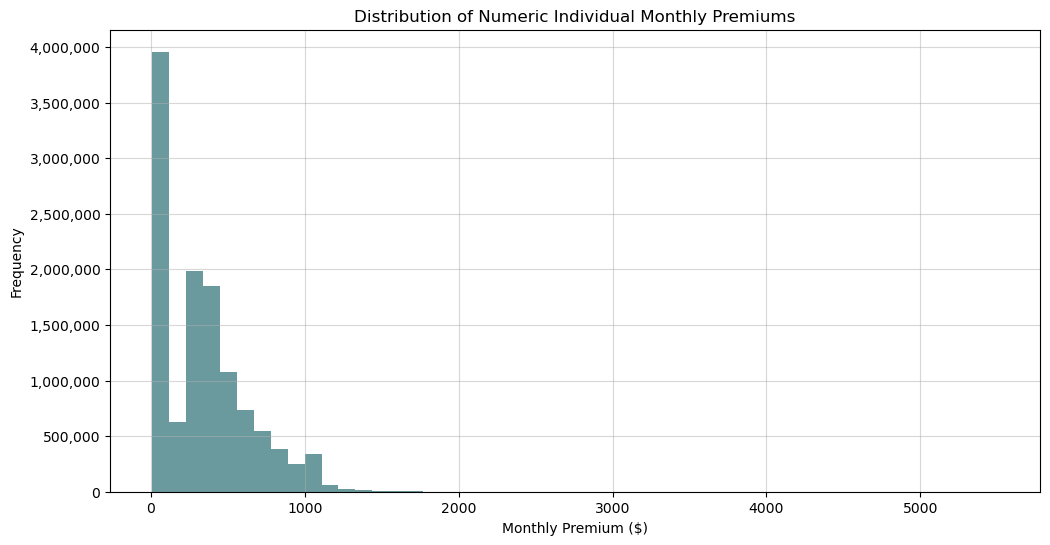

In [32]:
from matplotlib.ticker import StrMethodFormatter
plt.figure(figsize=(12,6))

plt.hist(df_eda["IndividualRate"], bins=50, color="#6A9A9E")

plt.title("Distribution of Numeric Individual Monthly Premiums")
plt.xlabel("Monthly Premium ($)")
plt.ylabel("Frequency")
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.grid(alpha=0.5)

plt.show()

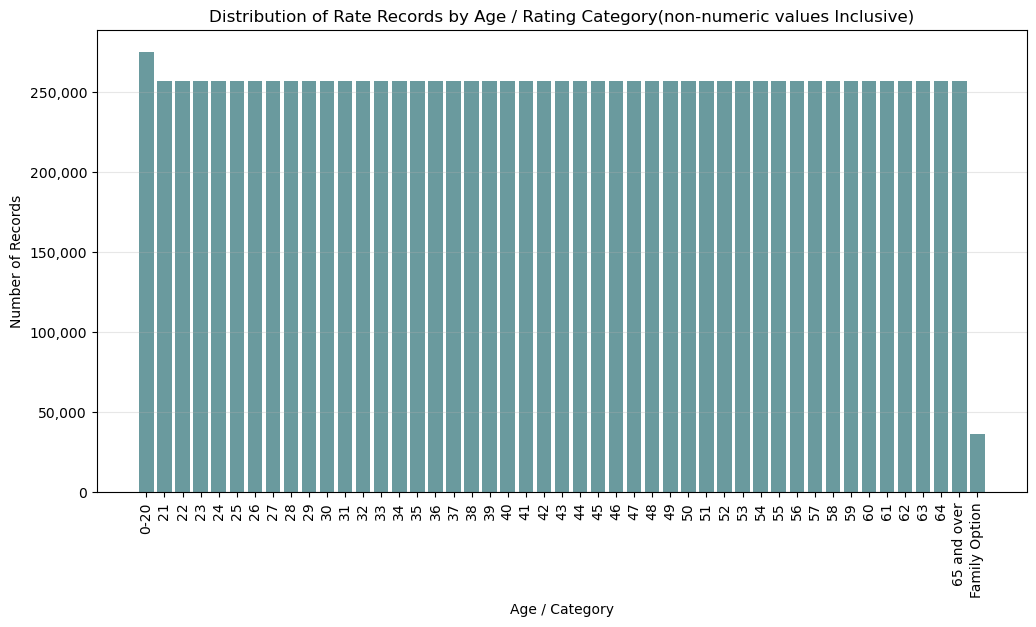

In [33]:
age_counts = df_eda["Age"].value_counts().sort_index()

# Separate numeric and non-numeric values
numeric_ages = sorted([x for x in age_counts.index if str(x).isdigit()], key=int)
non_numeric = [x for x in age_counts.index if not str(x).isdigit()]

# Build order explicitly: youngest band first, then numeric ages, then older band, then Family Option last
order = ['0-20'] + numeric_ages + ['65 and over', 'Family Option']

# Reorder counts
age_counts = age_counts.reindex(order)
# Plot
plt.figure(figsize=(12, 6))
plt.bar(age_counts.index.astype(str), age_counts.values,color="#6A9A9E")

plt.title("Distribution of Rate Records by Age / Rating Category(non-numeric values Inclusive)")
plt.xlabel("Age / Category")
plt.ylabel("Number of Records")
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)

plt.show()

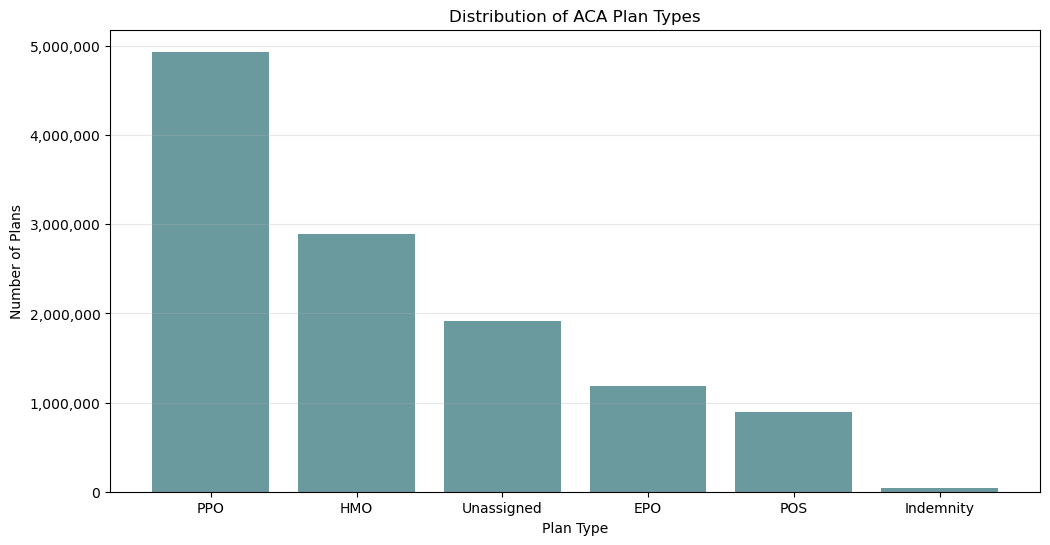

In [34]:
plan_counts = (df_eda["PlanType"].value_counts().sort_values(ascending=False))

plt.figure(figsize=(12,6))

plt.bar(plan_counts.index, plan_counts.values, color="#6A9A9E")

plt.title("Distribution of ACA Plan Types")
plt.xlabel("Plan Type")
plt.ylabel("Number of Plans")
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.grid(axis="y", alpha=0.3)

plt.show()

### **Findings:** Baseline Summary Statistics
IndividualRate (n = 11,872,828; after excluding zero and sentinel placeholder values)
Mean: $335.66 | Median: $308.72 | Standard Deviation: $298.27
Interquartile Range (IQR): $458.46 (Q1 = $33.24, Q3 = $491.70)
Range: $10.00 – $5,503.85
Skewness: 1.16, indicating a moderately right-skewed distribution. The mean exceeds the median, suggesting that a relatively small proportion of higher-priced plans increase the overall average premium. Consequently, the median ($308.72) provides a more representative measure of the typical monthly premium.
Age (n = 11,305,100)
Mean: 42.50 | Median: 43.00 | Standard Deviation: 12.70
Interquartile Range (IQR): 22.00 (Q1 = 32, Q3 = 54)
Range: 21 – 64
Skewness: ≈ 0.00, indicating an approximately symmetric distribution of numeric enrollee ages. Most observations fall between 32 and 54 years, with no substantial skew toward younger or older adult age groups.
Note on Sample Size

The numeric age summary contains 11,305,100 observations compared with 11,872,828 premium records, a difference of 567,728 rows. This discrepancy is expected because the Age field includes categorical rating classes (e.g., Family Option, 0-20, and 65 and over) that do not represent single numeric ages. These values were converted to NaN during numeric type conversion (pd.to_numeric(errors="coerce")) and excluded only from the numerical age analysis. They remain valid records and are retained for all other analyses, including premium, metal level, and plan type evaluations.


---

### 2. **Market Segmentation & Pricing Tiers**
#### *Metal Tier Segmentation & Coverage Analytics*

Objective

To analyze how ACA insurance plans differ across Metal Levels by examining premium costs, coverage characteristics, plan types, and deductible structures. The analysis aims to identify pricing patterns and trade-offs between lower-tier and higher-tier plans, providing insight into how the level of coverage is reflected in the cost and structure of available insurance plans.


Research Questions

* How do premium costs scale across ACA Metal Levels (Bronze, Silver, Gold, Platinum)?
* What coverages, plan types, and deductible structures are associated with low-tier vs. high-end tiers?


In [35]:
df_eda["MetalLevel"].value_counts(dropna=False)

MetalLevel
Silver          2952648
Gold            2223456
Unassigned      1921275
Bronze          1796806
Low             1216491
High            1012076
Platinum         579830
Catastrophic     170246
Name: count, dtype: int64

In [36]:
#Metal Tier Pricing & Coverage Architecture
metal_order = ['Bronze', 'Silver', 'Gold', 'Platinum', 'Catastrophic']

summary_rows = []

for tier in metal_order:
    tier_rates = (df_eda.loc[df_eda["MetalLevel"] == tier, "IndividualRate"].dropna().to_numpy())

    if len(tier_rates) == 0:
        continue

    q1 = np.percentile(tier_rates, 25)
    q3 = np.percentile(tier_rates, 75)

    summary_rows.append({
        "Metal Tier": tier,
        "Sample Size": len(tier_rates),
        "Mean": np.mean(tier_rates),
        "Median": np.median(tier_rates),
        "Std Dev": np.std(tier_rates),
        "Min": np.min(tier_rates),
        "Q1 (25%)": q1,
        "Q3 (75%)": q3,
        "Max": np.max(tier_rates),
        "IQR": q3 - q1,
        "Skewness": pd.Series(tier_rates).skew()
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.round(2)

,Metal Tier,Sample Size,Mean,Median,Std Dev,Min,Q1 (25%),Q3 (75%),Max,IQR,Skewness
0,Bronze,1796806,376.02,320.65,195.22,60.81,247.92,470.60,5255.15,222.68,4.33
1,Silver,2952648,460.96,393.78,212.55,69.48,308.10,581.85,5319.89,273.75,1.68
2,Gold,2223456,543.40,463.95,248.76,75.40,364.04,686.64,5503.85,322.60,1.50
3,Platinum,579830,610.16,527.08,280.48,97.04,403.73,768.83,2046.51,365.10,1.08
4,Catastrophic,170246,290.67,239.13,214.47,41.73,185.92,355.00,5354.51,169.08,9.10


In [37]:
plan_type_summary = (pd.crosstab(df_eda["MetalLevel"], df_eda["PlanType"]).reindex(metal_order).reset_index())

plan_type_summary

PlanType,MetalLevel,EPO,HMO,Indemnity,POS,PPO,Unassigned
0,Bronze,239614,661434,0,206954,688804,0
1,Silver,473432,1019590,3312,305118,1151196,0
2,Gold,281152,739174,3312,270894,928924,0
3,Platinum,76268,227056,3312,98440,174754,0
4,Catastrophic,24610,75762,0,15410,54464,0


Key Findings

Premiums increase steadily from Bronze to Platinum.
Silver plans account for the largest number of offerings.
HMO and PPO dominate across all metal tiers.
Catastrophic plans have the lowest average premiums and smallest market share.

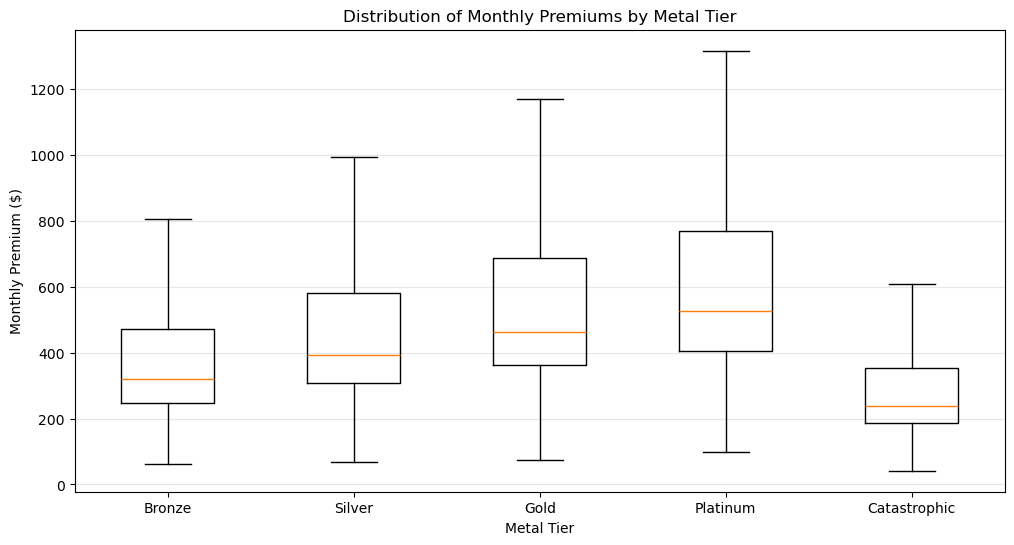

In [38]:
plt.figure(figsize=(12,6))

plt.boxplot([   
        df_eda.loc[df_eda["MetalLevel"]=="Bronze","IndividualRate"],
        df_eda.loc[df_eda["MetalLevel"]=="Silver","IndividualRate"],
        df_eda.loc[df_eda["MetalLevel"]=="Gold","IndividualRate"],
        df_eda.loc[df_eda["MetalLevel"]=="Platinum","IndividualRate"],
        df_eda.loc[df_eda["MetalLevel"]=="Catastrophic","IndividualRate"]
    ],tick_labels=metal_order,showfliers=False)

plt.title("Distribution of Monthly Premiums by Metal Tier")
plt.xlabel("Metal Tier")
plt.ylabel("Monthly Premium ($)")
plt.grid(axis="y", alpha=0.3)

plt.show()

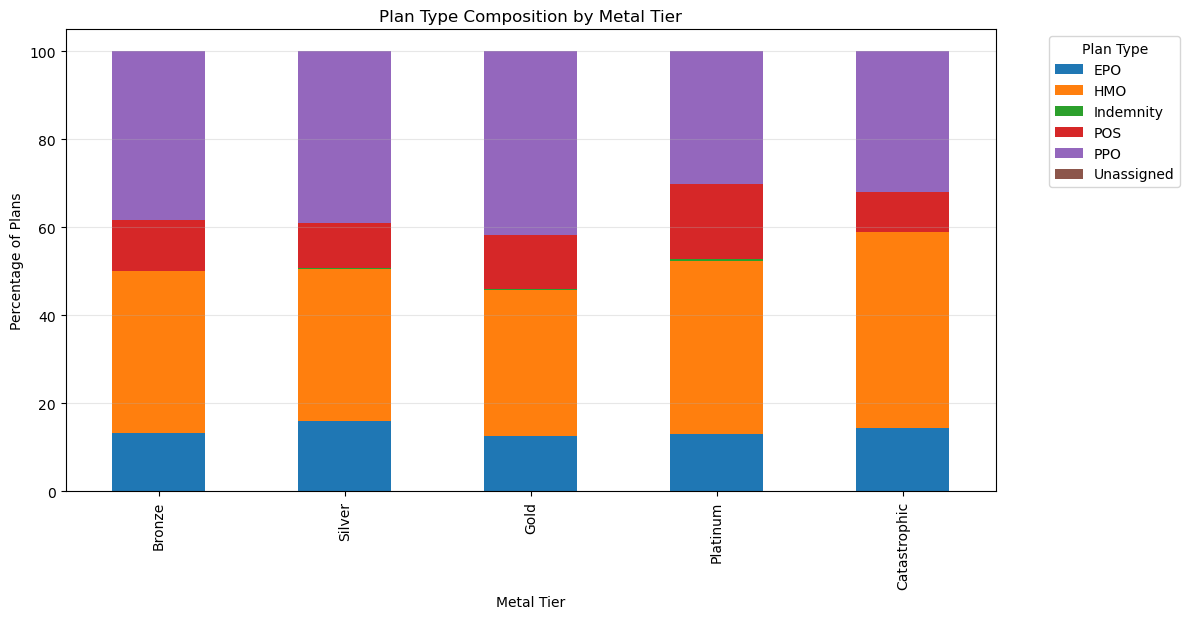

In [39]:
plan_type_pct = pd.crosstab(df_eda["MetalLevel"],df_eda["PlanType"],normalize="index").reindex(metal_order) * 100

plan_type_pct.plot(kind="bar",stacked=True,figsize=(12,6))

plt.title("Plan Type Composition by Metal Tier")
plt.xlabel("Metal Tier")
plt.ylabel("Percentage of Plans")
plt.legend(title="Plan Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis="y", alpha=0.3)

plt.show()

### **Findings:** Metal Tier Segmentation & Coverage Analytics

#### **Limitation**
Metal-level analyses are based on records successfully matched to PlanAttributes and therefore do not represent the full cleaned Rate dataset.

#### **Premium Scaling by Metal Tier**

Premiums increase consistently across the standard ACA metal hierarchy, reflecting the progressively richer coverage offered by higher-tier plans. Median monthly premiums rise from **Bronze ($320.65)** to **Silver ($393.78)**, **Gold ($463.95)**, and **Platinum ($527.08)**. Catastrophic plans have the lowest median premium (**$239.13**), reflecting their high-deductible, limited-eligibility design rather than a position within the standard Bronze–Platinum hierarchy.

The largest increase in median premium occurs between **Bronze** and **Silver** (approximately **$73.13**), corresponding to the transition from entry-level coverage to the ACA benchmark tier.

#### **Premium Variability & Distribution**

Not only do premiums increase across metal tiers, but pricing variability also widens with richer coverage. Platinum plans exhibit the largest interquartile range (**$365.10**), compared with **$222.68** for Bronze plans, indicating greater variation in pricing among high-coverage products.

All metal tiers display positive skewness, meaning a relatively small number of expensive plans pull the average premium above the median. Silver (1.68), Gold (1.50), and Platinum (1.08) show moderate positive skewness, while Bronze (4.33) and Catastrophic (9.10) have much higher skewness values. This indicates that Bronze and Catastrophic have more pronounced right-skewed distributions, where a small number of unusually expensive plans extend the upper tail and influence the mean. This makes the median a more representative measure of the typical monthly premium than the mean for this dataset.

The box plot further illustrates that while premiums generally rise across tiers, there is noticeable overlap between adjacent metal levels, suggesting that premium alone does not completely distinguish coverage tiers.

#### **Plan Type Composition**

Analysis of normalized plan-type distributions shows that **HMO** and **PPO** plans dominate the marketplace across every metal tier, accounting for the majority of available offerings regardless of coverage level.

Although the overall mix of plan types remains relatively consistent, some differences are evident. **POS** plans become slightly more prevalent in the **Gold** and **Platinum** tiers, while **Indemnity** plans represent only a negligible share of marketplace offerings across all tiers.

#### **Overall Interpretation**

The analysis demonstrates that **Metal Tier is strongly associated with premium level and pricing variability**, with higher coverage tiers commanding higher monthly premiums and exhibiting greater dispersion in pricing. In contrast, **plan type composition changes only modestly across tiers**, indicating that ACA metal levels primarily differentiate the financial structure of coverage rather than the underlying provider network model.


---
### 3. **Geographic & Regional Variance**

####   *Geographic & Regional Rate Analysis*


Objective:

Analyze how health insurance premiums vary across geographic regions by comparing premium levels and variability across states, counties, rating areas, and service areas.

Research Questions:
* Which states per year exhibit the highest and lowest average premium rates?
* Which rating areas or service areas have the highest and lowest average premium rates?
* How much does premium variability differ across states?

In [40]:
state_rankings = df_eda.groupby(['StateCode', 'BusinessYear'])['IndividualRate'].agg(
    avg_premium='mean',
    median_premium='median',
    min_premium='min',
    max_premium='max',
    total_records='count'
).reset_index()

# Top 5 Most Expensive States
top_5_states_each_year = state_rankings.sort_values(['BusinessYear', 'median_premium'], ascending=[True, False]).groupby('BusinessYear').head(5).set_index('BusinessYear')

# Top 5 Least Expensive States
bottom_5_states_each_year = state_rankings.sort_values(['BusinessYear', 'median_premium'], ascending=[True, True]).groupby('BusinessYear').head(5).set_index('BusinessYear')

print("HIGHEST MEDIAN PREMIUM STATES PER YEAR")
top_5_states_each_year[['StateCode', 'avg_premium', 'median_premium']]



HIGHEST MEDIAN PREMIUM STATES PER YEAR


,StateCode,avg_premium,median_premium
BusinessYear,,,
2014,AK,687.484651,610.810
2014,NJ,433.632389,426.145
2014,WY,451.446491,420.735
2014,IN,470.489878,418.490
2014,WI,474.703744,414.880
2015,AK,664.414428,584.280
2015,WY,462.906144,438.700
2015,NJ,456.468964,437.430
2015,WI,483.611017,423.150


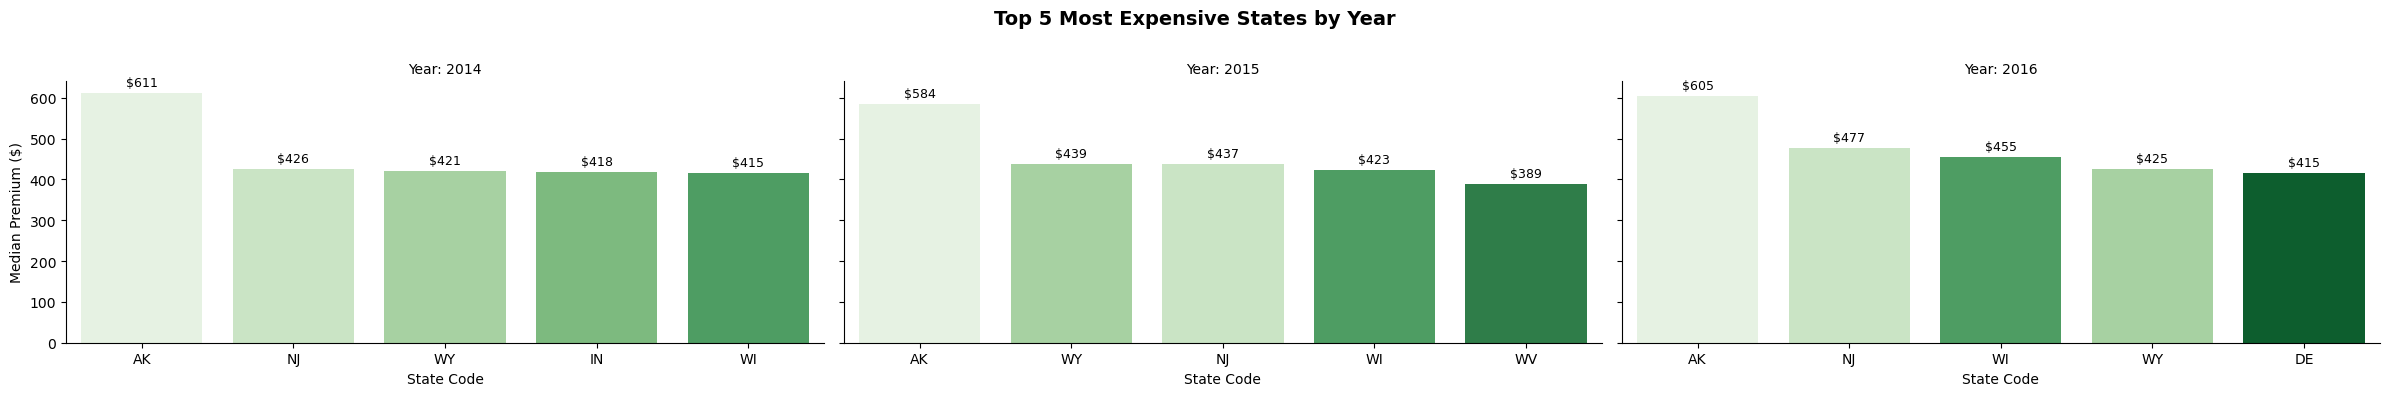

In [41]:
# Plot separate panels per year
g = sns.catplot(
    data=top_5_states_each_year.reset_index(),
    x='StateCode',
    y='median_premium',
    col='BusinessYear',
    kind='bar',
    hue='StateCode',
    palette='Greens',
    height=4,
    aspect=2,
    sharex=False 
)
# 1. Add data labels above each bar
for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f'${height:.0f}',
                (p.get_x() + p.get_width() / 2.0, height),
                ha='center',
                va='bottom',
                fontsize=9,
                xytext=(0, 3),
                textcoords='offset points'
            )


g.set_axis_labels("State Code", "Median Premium ($)")
g.set_titles("Year: {col_name}")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Top 5 Most Expensive States by Year", fontsize=14, fontweight='bold')

plt.show()

In [42]:
print("LOWEST MEDIAN PREMIUM STATES PER YEAR")
bottom_5_states_each_year[['StateCode', 'avg_premium', 'median_premium']]

LOWEST MEDIAN PREMIUM STATES PER YEAR


,StateCode,avg_premium,median_premium
BusinessYear,,,
2014,MO,157.784407,32.05
2014,WV,212.414447,33.13
2014,AR,191.728140,36.40
2014,GA,239.883794,41.63
2014,FL,224.603366,99.00
2015,IN,244.981070,33.87
2015,MO,163.612090,34.30
2015,NE,246.411712,40.55
2015,OH,264.179821,48.90


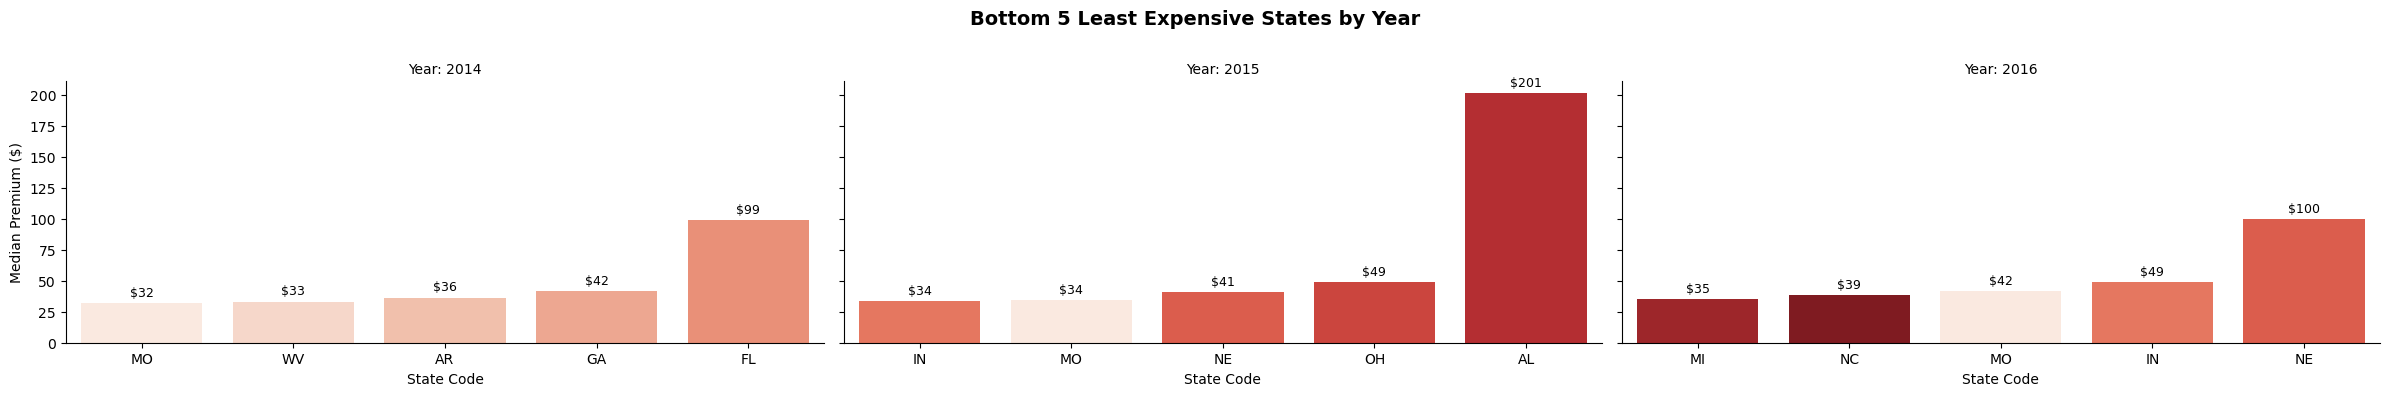

In [43]:
# Plot separate panels per year
g = sns.catplot(
    data=bottom_5_states_each_year.reset_index(),
    x='StateCode',
    y='median_premium',
    col='BusinessYear',
    kind='bar',
    hue="StateCode",
    palette='Reds',
    height=4,
    aspect=2,
    sharex=False 
)
# 1. Add data labels above each bar
for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f'${height:.0f}',
                (p.get_x() + p.get_width() / 2.0, height),
                ha='center',
                va='bottom',
                fontsize=9,
                xytext=(0, 3),
                textcoords='offset points'
            )


g.set_axis_labels("State Code", "Median Premium ($)")
g.set_titles("Year: {col_name}")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Bottom 5 Least Expensive States by Year", fontsize=14, fontweight='bold')

plt.show()

In [44]:
rating_area_rankings = pd.read_sql("""
    SELECT StateCode, RatingAreaId, IndividualRate
    FROM Rate
    WHERE IndividualRate >= 10.00
    AND IndividualRate NOT IN (9990.00, 9999, 99999, 999999)
    """, conn)

rating_area_rankings = (rating_area_rankings.groupby(["StateCode", "RatingAreaId"])["IndividualRate"].agg(
        avg_premium="mean",
        median_premium="median",
        min_premium="min",
        max_premium="max",
        plan_count="count"
    ).reset_index())

# remove rating areas with very few records
rating_area_rankings = rating_area_rankings[rating_area_rankings["plan_count"] >= 10]

top_10_rating = rating_area_rankings.nlargest(10, "median_premium")
bottom_10_rating = rating_area_rankings.nsmallest(10, "median_premium")

print("HIGHEST MEDIAN PREMIUM RATING AREAS")
top_10_rating[["StateCode", "RatingAreaId", "avg_premium", "median_premium"]]

HIGHEST MEDIAN PREMIUM RATING AREAS


,StateCode,RatingAreaId,avg_premium,median_premium
0,AK,Rating Area 1,676.616033,602.175
1,AK,Rating Area 2,674.372476,599.000
2,AK,Rating Area 3,668.352320,593.270
256,NJ,Rating Area 6,479.980518,473.350
417,WI,Rating Area 4,523.967074,464.500
255,NJ,Rating Area 5,467.889429,462.195
254,NJ,Rating Area 4,462.696741,460.615
421,WI,Rating Area 8,512.908977,451.340
252,NJ,Rating Area 2,456.326228,450.040
407,WI,Rating Area 1,509.389000,449.510


In [45]:
print("LOWEST MEDIAN PREMIUM RATING AREAS")
bottom_10_rating[["StateCode", "RatingAreaId", "avg_premium", "median_premium"]]

LOWEST MEDIAN PREMIUM RATING AREAS


,StateCode,RatingAreaId,avg_premium,median_premium
40,FL,Rating Area 18,181.502728,29.19
52,FL,Rating Area 29,172.681898,29.19
55,FL,Rating Area 31,171.550697,29.19
62,FL,Rating Area 38,183.897038,29.19
63,FL,Rating Area 39,176.366985,29.19
89,FL,Rating Area 62,173.136247,29.19
94,FL,Rating Area 67,174.370723,29.19
95,FL,Rating Area 7,176.620620,29.19
41,FL,Rating Area 19,187.412961,29.68
47,FL,Rating Area 24,191.888363,29.68


In [46]:
# Premium variability by state
state_variability = df_eda.groupby('StateCode')['IndividualRate'].agg(
    avg_premium='mean',
    median_premium="median",
    std_premium='std',
    min_premium='min',
    max_premium='max',
    range_premium=lambda x: x.max() - x.min(),
    total_records='count').reset_index()

# Coefficient of variation = std / mean, expressed as %
# I compared "relative" variability across states with very different price levels
state_variability['coeff_of_variation_pct'] = (state_variability['std_premium'] / state_variability['avg_premium'] * 100).round(2)

state_variability = state_variability.round(2)

# Rank by Coefficient of Variation (%) for true relative price dispersion
most_variable = state_variability.nlargest(10, "coeff_of_variation_pct")
least_variable = state_variability.nsmallest(10, "coeff_of_variation_pct")

print("MOST VARIABLE STATES (Highest spread relative to average premium)")
display(most_variable[["StateCode", "avg_premium", "median_premium", "std_premium", "coeff_of_variation_pct", "total_records"]])

MOST VARIABLE STATES (Highest spread relative to average premium)


,StateCode,avg_premium,median_premium,std_premium,coeff_of_variation_pct,total_records
16,MO,182.78,36.57,234.15,128.11,130828
35,VA,348.37,271.34,444.81,127.68,298179
19,NC,309.32,127.85,342.87,110.85,335702
15,MI,248.74,136.43,273.60,109.99,978502
6,GA,306.12,256.91,315.19,102.97,440706
26,OH,297.69,253.70,306.07,102.81,844546
33,TX,247.36,205.36,254.12,102.74,780914
1,AL,278.00,236.32,282.90,101.76,175056
5,FL,280.39,259.55,276.60,98.65,1566432
2,AR,242.39,226.92,233.62,96.38,73093


In [47]:
print("LEAST VARIABLE STATES (Lowest relative premium dispersion)")
least_variable[["StateCode", "avg_premium", "median_premium", "std_premium", "coeff_of_variation_pct", "total_records"]]

LEAST VARIABLE STATES (Lowest relative premium dispersion)


,StateCode,avg_premium,median_premium,std_premium,coeff_of_variation_pct,total_records
0,AK,673.12,598.00,372.05,55.27,78722
36,WI,493.61,433.55,286.41,58.02,979246
34,UT,288.45,271.50,172.30,59.73,77272
31,SD,397.04,360.40,245.15,61.74,69520
23,NJ,458.83,452.15,284.87,62.09,159271
9,ID,335.59,304.02,210.08,62.60,64717
22,NH,385.80,334.85,247.89,64.25,16556
27,OK,354.32,315.57,238.63,67.35,174262
3,AZ,368.60,325.76,251.35,68.19,332196
14,ME,395.97,350.90,270.53,68.32,65324


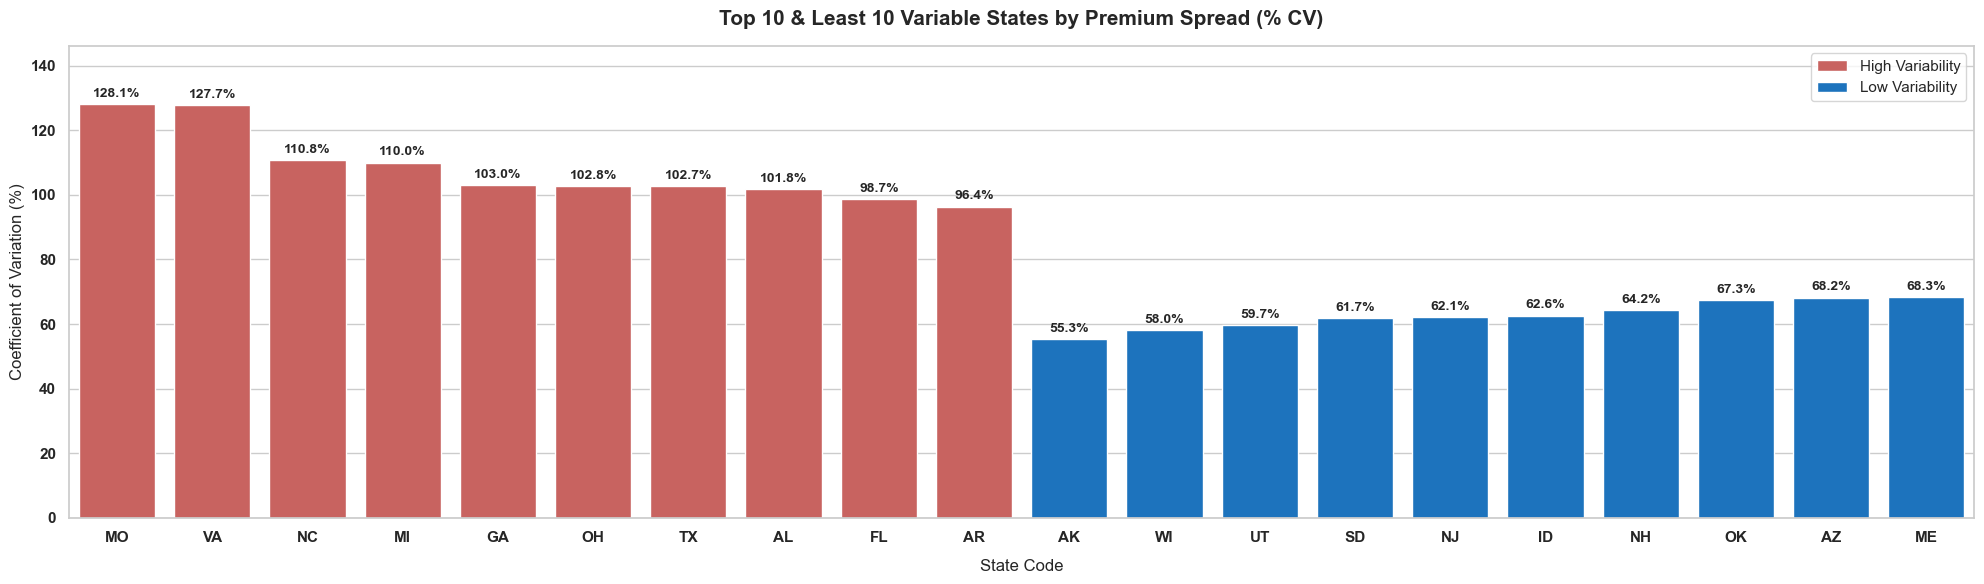

In [48]:
# Combine Top 10 Most Variable and Top 10 Least Variable States
most_variable_10 = most_variable.head(10).copy()
least_variable_10 = least_variable.head(10).copy()

# Adding a group flag to color-code high vs. low variability
most_variable_10['Group'] = 'High Variability'
least_variable_10['Group'] = 'Low Variability'

plot_data = pd.concat([most_variable_10, least_variable_10]).reset_index(drop=True)

plt.figure(figsize=(20, 6))
sns.set_theme(style="whitegrid")

# Create bar plot
ax = sns.barplot(
    data=plot_data,
    x='StateCode',
    y='coeff_of_variation_pct',
    hue='Group',
    palette={'High Variability': '#d9534f', 'Low Variability': '#0275d8'},
    dodge=False
)

# Adding the direct percentage labels above each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            xytext=(0, 3),
            textcoords='offset points'
        )

# Titles & Axis Labels
plt.title('Top 10 & Least 10 Variable States by Premium Spread (% CV)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('State Code', fontsize=12, labelpad=10)
plt.ylabel('Coefficient of Variation (%)', fontsize=12)
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')
plt.ylim(0, plot_data['coeff_of_variation_pct'].max() + 18)
plt.legend(title='', fontsize=11, loc='upper right')

# Display plot
plt.tight_layout()
plt.show()

### Findings: Geographic & Regional Rate Analysis

**State-level premium rankings (2014–2016):**
Average premiums vary substantially across states, with the highest-average states (e.g., Alaska, $673.12/month) priced roughly 3.7× higher than the lowest-average state. These differences show substantial geographic variation in listed premiums across the ACA Marketplace, although the available data does not allow the specific effects of healthcare costs, provider network pricing, or market competition to be isolated.

**Premium variability across states (ranked by Coefficient of Variation):**

Rather than ranking states by raw standard deviation, premiums were compared using the coefficient of variation (CoV = standard deviation / mean), since raw spread alone can conflate an "expensive state" with an "inconsistent state." CoV normalizes for price level, allowing a fair comparison of relative price dispersion. The analysis calculated CoV as the standard deviation divided by the average premium and expressed it as a percentage.

| Rank | Most Variable (highest CoV) | CoV | Most Consistent (lowest CoV) | CoV |
|---|---|---|---|---|
| 1 | Missouri | 128.11% | Alaska | 55.27% |
| 2 | Virginia | 127.68% | Wisconsin | 58.02% |
| 3 | North Carolina | 110.85% | Utah | 59.73% |

Premium variability differed substantially across states. Missouri and Virginia exhibited the greatest relative variability, with CoVs of approximately 128%, indicating a wide dispersion of premiums relative to their state-level averages. This may reflect differences in the mix of plan tiers, issuers, or regional pricing areas within these states. In contrast, Alaska and Wisconsin had the lowest coefficients of variation, at approximately 55–58%. Alaska's result is particularly notable because it had the highest average premium overall, demonstrating that a state with higher average premiums does not necessarily have the greatest relative premium variability.

These findings indicate that premium prices can vary considerably between states and that the degree of relative price dispersion also differs across the marketplace.

**Reliability note:** All states shown in both rankings have substantial sample sizes (>16,000 records), supporting confidence in these comparisons. Hawaii, which has a notably smaller sample (n = 1,473) in the full dataset, was not among the extremes in this corrected CoV-based ranking.

**Limitations:**
- Rankings combine all three years (2014–2016); therefore, changes in premiums over time may be mixed with geographic differences.
- The analysis identifies geographic differences in listed premiums but does not establish that healthcare costs, provider network pricing, or market competition caused those differences.
- County and service-area-level analysis was not included because these identifiers would need to be treated as categorical/string variables for meaningful grouping and interpretation.


---

### 4. **Key Market Relationships**
### *Visualizing Relationships Between Premium Drivers*

Objective

Visualize and explore the relationships between key factors influencing ACA health insurance premiums, including age, tobacco use, and metal tier, to identify pricing patterns and interactions.

Research Questions

* How do premiums change across different age groups?
* What is the impact of tobacco use on premium rates?
* How do premium distributions differ across ACA metal tiers?
* How do age, tobacco status, and metal tier jointly influence premium pricing?


In [49]:
market_data = pd.read_sql("""SELECT 
                                Age, 
                                Tobacco, 
                                IndividualRate, 
                                IndividualTobaccoRate,
                                r.PlanId, 
                                r.IssuerId, 
                                r.StateCode, 
                                r.BusinessYear
    FROM Rate r
    WHERE IndividualRate >= 10.00
    AND IndividualRate NOT IN (9999.99, 9999, 99999, 999999)
    """, conn)

market_data['Age_num'] = pd.to_numeric(market_data['Age'], errors='coerce')

metal_lookup = pd.read_sql("""SELECT DISTINCT 
                                            StandardComponentId, 
                                            IssuerId, 
                                            StateCode, 
                                            BusinessYear, 
                                            MetalLevel
    FROM PlanAttributes
    WHERE SUBSTR(PlanId, -2) = '00'
    """, conn)

market_data = market_data.merge(metal_lookup,
    left_on=['PlanId', 'IssuerId', 'StateCode', 'BusinessYear'],
    right_on=['StandardComponentId', 'IssuerId', 'StateCode', 'BusinessYear'],
    how='left')

market_data

,Age,Tobacco,IndividualRate,IndividualTobaccoRate,PlanId,IssuerId,StateCode,BusinessYear,Age_num,StandardComponentId,MetalLevel
0,0-20,No Preference,29.00,,21989AK0010001,21989,AK,2014,NaN,21989AK0010001,Low
1,Family Option,No Preference,36.95,,21989AK0020001,21989,AK,2014,NaN,21989AK0020001,High
2,Family Option,No Preference,36.95,,21989AK0020001,21989,AK,2014,NaN,21989AK0020001,High
3,21,No Preference,32.00,,21989AK0010001,21989,AK,2014,21.0,21989AK0010001,Low
4,22,No Preference,32.00,,21989AK0010001,21989,AK,2014,22.0,21989AK0010001,Low
...,...,...,...,...,...,...,...,...,...,...,...
11872823,61,No Preference,14.05,,96480WV0090003,96480,WV,2016,61.0,96480WV0090003,Low
11872824,62,No Preference,14.05,,96480WV0090003,96480,WV,2016,62.0,96480WV0090003,Low
11872825,63,No Preference,14.05,,96480WV0090003,96480,WV,2016,63.0,96480WV0090003,Low
11872826,64,No Preference,14.05,,96480WV0090003,96480,WV,2016,64.0,96480WV0090003,Low


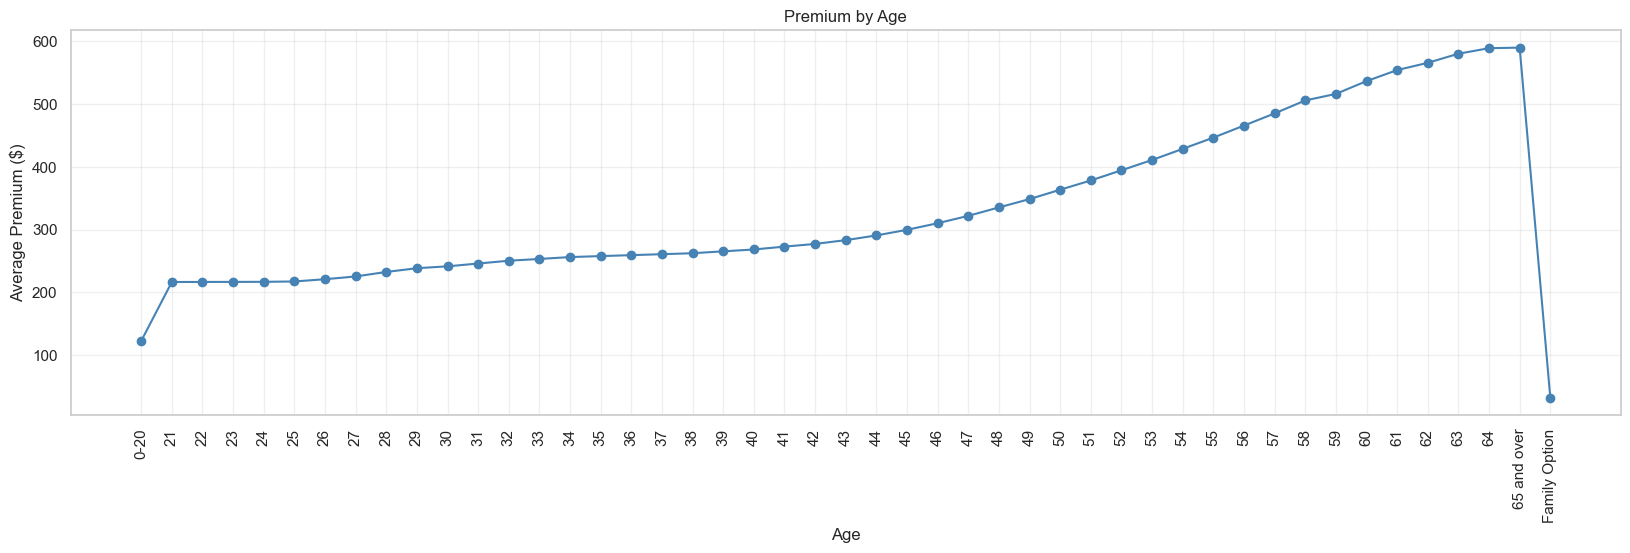

In [50]:
age_curve = market_data.groupby('Age')['IndividualRate'].mean().reset_index()

plt.figure(figsize=(20, 5))
plt.plot(age_curve['Age'], age_curve['IndividualRate'], marker='o', color='steelblue')
plt.xticks(rotation=90)
plt.xlabel('Age')
plt.ylabel('Average Premium ($)')
plt.title('Premium by Age')
plt.grid(alpha=0.3)
plt.show()

In [51]:
#Convert columns to numeric and removing the possible nulls
market_data["IndividualRate"] = pd.to_numeric(market_data["IndividualRate"], errors="coerce")

market_data["IndividualTobaccoRate"] = pd.to_numeric(market_data["IndividualTobaccoRate"], errors="coerce")

In [52]:
#Remove NAN from the Age_num colmn
market_data = market_data.dropna(subset=['Age_num'])

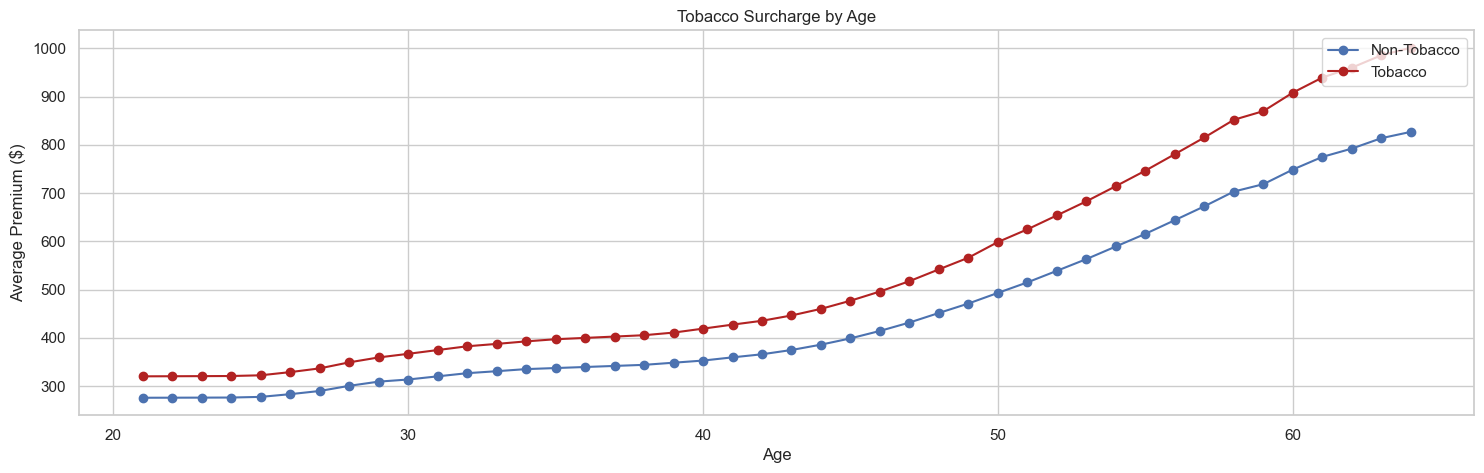

Average tobacco surcharge: 18.9%


In [53]:
tobacco_summary = market_data.dropna(subset=['IndividualTobaccoRate']).groupby('Age_num')[['IndividualRate', 'IndividualTobaccoRate']].mean().reset_index()
tobacco_summary['surcharge_pct'] = ((tobacco_summary['IndividualTobaccoRate'] - tobacco_summary['IndividualRate'])  / tobacco_summary['IndividualRate'] * 100)

plt.figure(figsize=(18, 5))
plt.plot(tobacco_summary['Age_num'], tobacco_summary['IndividualRate'], marker='o', label='Non-Tobacco')
plt.plot(tobacco_summary['Age_num'], tobacco_summary['IndividualTobaccoRate'], marker='o', color='firebrick', label='Tobacco')
plt.xlabel('Age')
plt.ylabel('Average Premium ($)')
plt.title('Tobacco Surcharge by Age')
plt.legend(title='', fontsize=11, loc='upper right')
plt.show()

print(f"Average tobacco surcharge: {tobacco_summary['surcharge_pct'].mean():.1f}%")

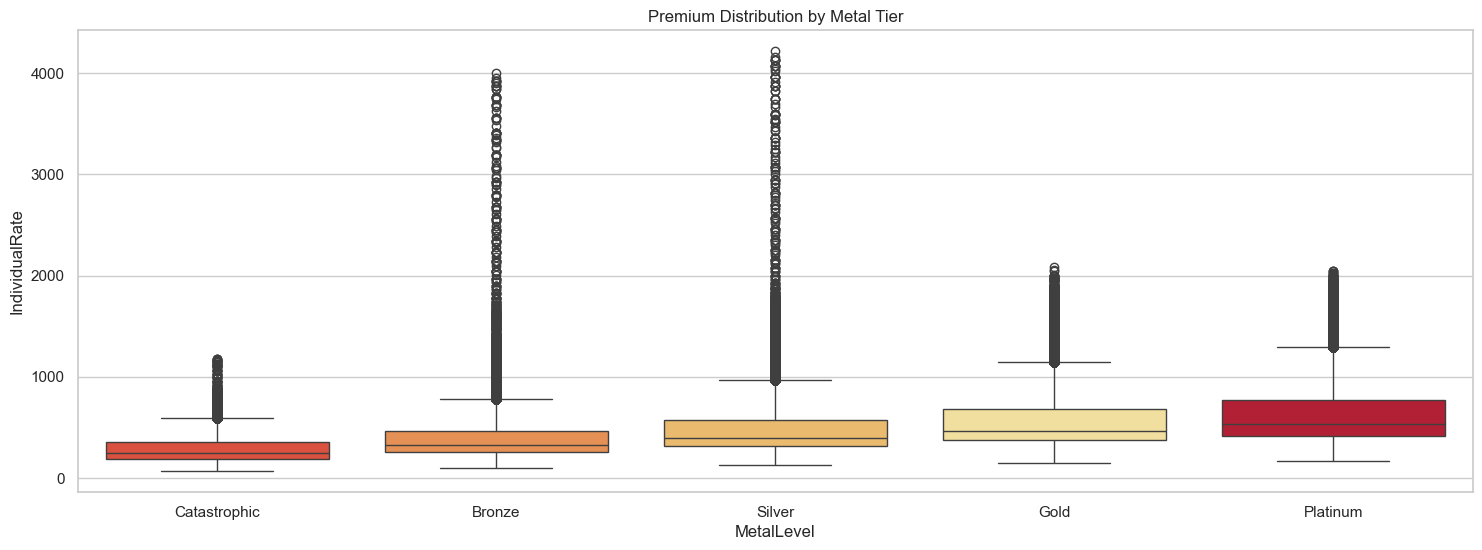

In [54]:
tier_order = ['Catastrophic', 'Bronze', 'Silver', 'Gold', 'Platinum']
plot_data = market_data[market_data['MetalLevel'].isin(tier_order)]

plt.figure(figsize=(18, 6))
sns.boxplot(data=plot_data, x='MetalLevel', y='IndividualRate', hue='MetalLevel', order=tier_order, palette='YlOrRd')
plt.title('Premium Distribution by Metal Tier')
plt.show()

In [55]:
joint_data = market_data.dropna(subset=["MetalLevel"]).copy()
joint_data = joint_data[joint_data["MetalLevel"].isin(tier_order)]

# Keep only rows where both premiums exist
joint_data = joint_data.dropna(subset=["IndividualRate", "IndividualTobaccoRate"])

# Convert from wide to long format
joint_long = joint_data.melt(
    id_vars=["Age_num", "MetalLevel"],
    value_vars=["IndividualRate", "IndividualTobaccoRate"],
    var_name="TobaccoStatus",
    value_name="Premium")

# Rename the tobacco categories
joint_long["TobaccoStatus"] = joint_long["TobaccoStatus"].replace({
    "IndividualRate": "Non-Tobacco",
    "IndividualTobaccoRate": "Tobacco"})

In [56]:
joint_summary = (joint_long.groupby(["Age_num", "MetalLevel", "TobaccoStatus"])["Premium"].mean().reset_index())

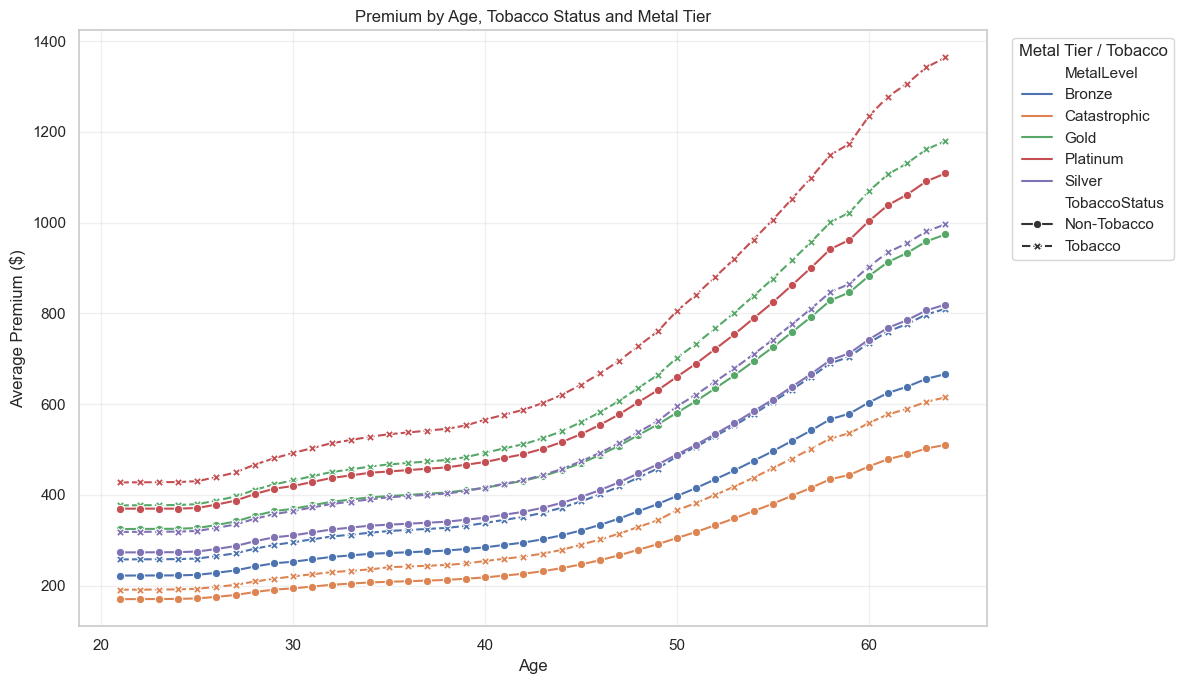

In [57]:
plt.figure(figsize=(12, 7))

sns.lineplot(
    data=joint_summary,
    x="Age_num",
    y="Premium",
    hue="MetalLevel",          # Color = Metal Tier
    style="TobaccoStatus",     # Solid vs dashed = Tobacco
    markers=True,
    dashes=True
)

plt.title("Premium by Age, Tobacco Status and Metal Tier")
plt.xlabel("Age")
plt.ylabel("Average Premium ($)")
plt.grid(alpha=0.3)
plt.legend(title="Metal Tier / Tobacco", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Findings: Key Market Relationships
Premiums increased consistently with age across all ACA metal tiers. Tobacco-rated premiums remained higher than non-tobacco premiums at every age, demonstrating a persistent tobacco surcharge. The expected pricing hierarchy (Catastrophic < Bronze < Silver < Gold < Platinum) was maintained regardless of tobacco status. Premium growth accelerated after approximately ages 45–50, indicating that age exerts an increasingly strong influence on premium pricing in later adulthood. The combination of older age, tobacco use, and higher metal tiers resulted in the highest average premiums.

---

## Conclusion

### Key Takeaways

- **Premiums increased steadily from Bronze to Platinum.** Median monthly premiums rose from **$320.65 for Bronze** to **$393.78 for Silver**, **$463.95 for Gold**, and **$527.08 for Platinum**, showing a clear upward pricing pattern across the standard metal tiers.

- **Catastrophic plans had the lowest typical premiums.** Their median premium was **$239.13**, although Catastrophic plans represent a distinct coverage category rather than part of the Bronze–Platinum progression.

- **Premium distributions were right-skewed across all metal tiers.** Silver (**1.68**), Gold (**1.50**), and Platinum (**1.08**) showed moderate positive skewness, while Bronze (**4.33**) and Catastrophic (**9.10**) had substantially higher skewness. This makes the **median a more representative measure of typical premium levels than the mean**.

- **Silver plans accounted for the largest number of analyzed records**, followed by Gold, Bronze, Platinum, and Catastrophic plans.

- **PPO and HMO dominated marketplace offerings.** PPO accounted for **42.76%** and HMO for **39.75%** of the observed plan records, together representing approximately **82.5%** of the marketplace records.

- **PPO and HMO remained dominant across metal tiers.** Their large representation was consistent across Bronze, Silver, Gold, Platinum, and Catastrophic plans, indicating that these two plan types formed the core of the observed marketplace offerings.

- **Premiums varied substantially across states.** Alaska had the highest average premium at approximately **$673.12 per month**, about **3.7×** the average premium of the lowest-average state in the combined 2014–2016 analysis.

- **Relative premium variability differed substantially across states.** Missouri and Virginia had the highest coefficients of variation at approximately **128%**, while Alaska, Wisconsin, and Utah had the lowest among the states examined. Alaska's result was particularly notable because it had the highest average premium but one of the lowest relative variability levels.

- **Tobacco-rated premiums were higher than non-tobacco premiums.** The analysis estimated an average tobacco surcharge of approximately **18.9%**, indicating a notable difference between tobacco-rated and non-tobacco rates in the analyzed records.

- **Premiums increased with age across metal tiers.** Average premiums increased consistently with age, while tobacco-rated premiums remained higher than non-tobacco premiums at every age. Premium growth accelerated after approximately **ages 45–50**, with the combination of older age, tobacco status, and higher metal tiers producing the highest average premiums.

### Data Limitations
* The analysis is based on ACA Marketplace filings from 2014–2016 and may not fully reflect the current health insurance market.
* Premiums do not account for government subsidies or tax credits that reduce the amount many consumers actually pay.
* IndividualRate represents the listed monthly premium rather than the actual out-of-pocket premium paid by enrollees.
* Plan popularity and enrollment counts were unavailable, preventing analysis of which plans consumers selected most frequently.
* Medical claims and healthcare utilization data were not included, limiting the ability to relate premiums to actual healthcare costs or outcomes.
* Insurer names were represented only by IssuerId, preventing meaningful insurer-level comparisons and reducing the interpretability of company specific analyses.
### Geographic Limitations
* The analysis primarily focused on state level geographic variation. Differences within smaller geographic areas, such as counties, neighborhoods, or provider service availability, were outside the scope of this project.
* The dataset does not include regional healthcare cost drivers such as hospital pricing, physician fees, or healthcare utilization making it difficult to explain the underlying causes of geographic premium differences.
### Analysis Limitations
* This is an exploratory data analysis (EDA) and identifies patterns and associations rather than causal relationships. Consequently, observed premium differences cannot be attributed to a single determining factor.
* The raw dataset contained placeholder and anomalous values that required preprocessing. Although these records were carefully identified and handled, preprocessing decisions may have a small influence on the reported summary statistics.
* The project does not include predictive or machine learning models and therefore does not forecast future premiums or estimate premium changes.
### Business Limitations
* Premiums were evaluated independently of plan quality metrics such as customer satisfaction, claim approval rates, provider network quality, or healthcare outcomes.
* Although metal tiers indicate the general generosity of coverage, plans within the same tier may differ substantially in deductibles, copayments, coinsurance, and covered services. These plan-specific differences were not analyzed in detail.

## Disclaimer

The analysis relied on successfully joining multiple CMS datasets using plan identifiers. Any inconsistencies or missing records across source tables may have reduced the completeness of certain analyses.